# Instances

A **cell instance** is a pointer to an existing cell placed inside another cell.
The instance itself contains no geometry — it only records *which* cell to show,
and *where* (position, rotation, mirror).

Key benefits:

- **Memory efficiency** — one cell definition, many placements.
- **Consistency** — modify the original cell and every instance updates automatically.
- **Hierarchy** — build circuits from subcircuits without flattening.

In [1]:
import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGEX: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)
    FLOORPLAN: kf.kdb.LayerInfo = kf.kdb.LayerInfo(10, 0)


L = LAYER()
kf.kcl.infos = L

## Creating an instance

Use `cell.create_inst(child)` or the `<<` shorthand to place a child cell inside a
parent.  Both forms return an `Instance` object that you can move, rotate, or mirror
after creation.

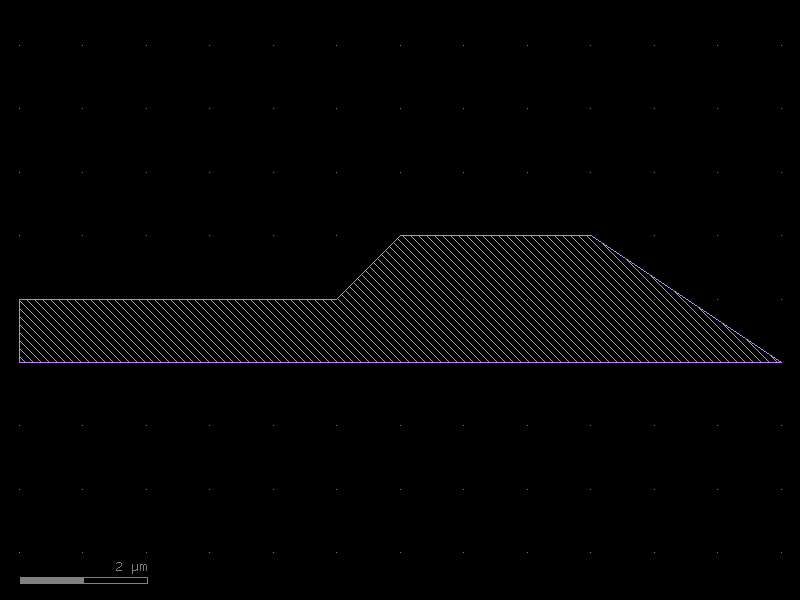

In [2]:
# Build a simple polygon cell to reuse
poly = kf.KCell(name="polygon_source")
xpts = [0, 0, 5, 6, 9, 12]
ypts = [0, 1, 1, 2, 2, 0]
poly.shapes(kf.kcl.find_layer(L.WGEX)).insert(
    kf.kdb.DPolygon([kf.kdb.DPoint(x, y) for x, y in zip(xpts, ypts)])
)
poly

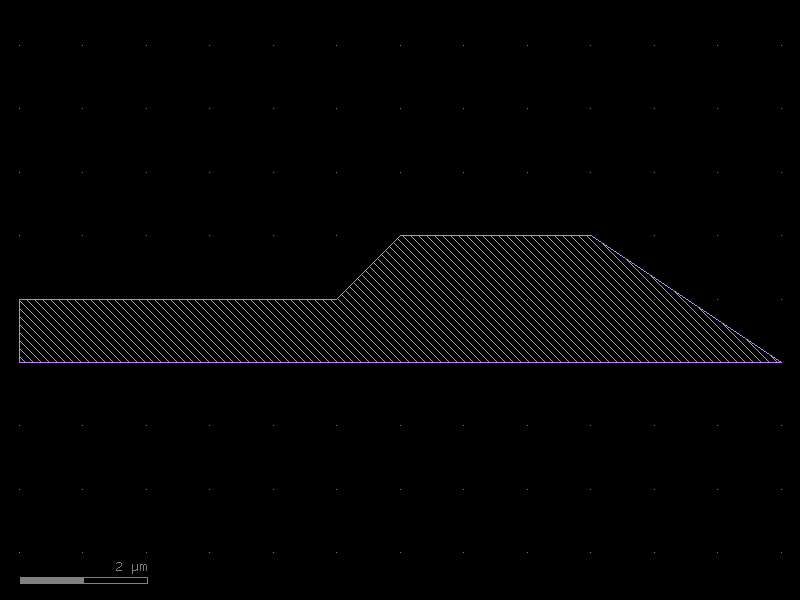

In [3]:
# Long form: create_inst
parent = kf.KCell(name="three_instances")
inst1 = parent.create_inst(poly)

# Short form: << operator (exactly equivalent)
inst2 = parent << poly
inst3 = parent << poly

parent

All three instances overlap because they share the same default position.
We can move them independently without touching the original cell.

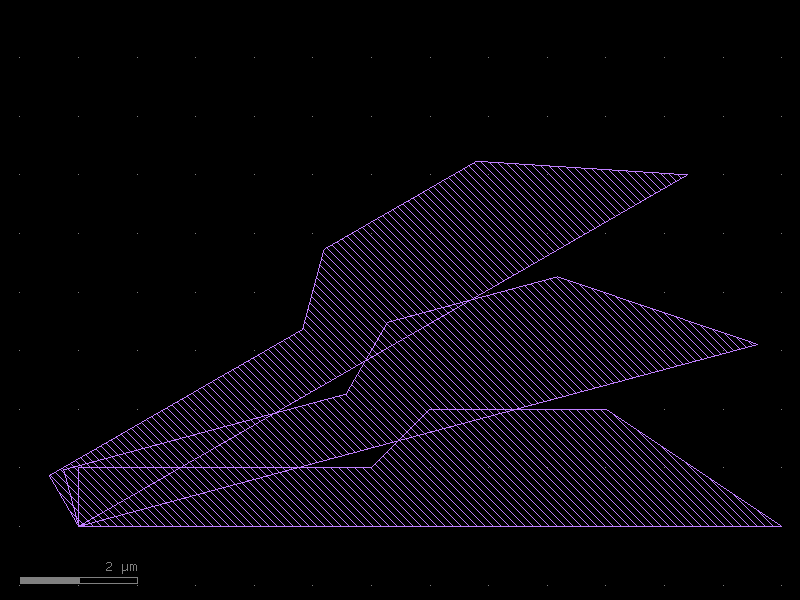

In [4]:
inst2.transform(kf.kdb.DCplxTrans(1, 15, False, 0, 0))   # rotate 15°
inst3.transform(kf.kdb.DCplxTrans(1, 30, False, 0, 0))   # rotate 30°
parent

## Modifying the original propagates everywhere

Instances are live pointers.  Adding geometry to `poly` is immediately visible in
every instance — without touching `parent`.

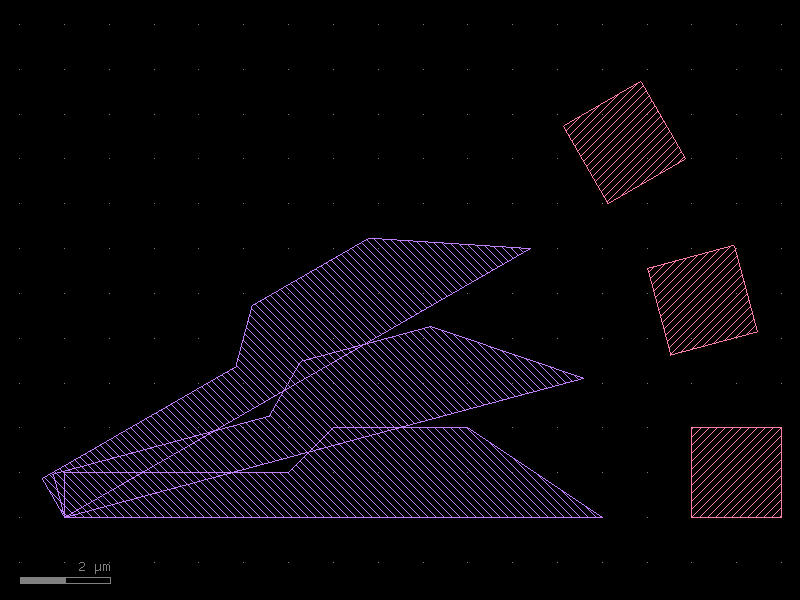

In [5]:
poly.shapes(kf.kcl.find_layer(L.WG)).insert(
    kf.kdb.DPolygon([kf.kdb.DPoint(x, y) for x, y in zip([14, 14, 16, 16], [0, 2, 2, 0])])
)
parent   # all three instances now show the extra rectangle

## Transforming instances

An `Instance` wraps a KLayout `CellInstArray`.  You can apply any KLayout
transformation to reposition it:

| Transform type | Preserves angles? | Floating-point coords? |
|----------------|-------------------|------------------------|
| `Trans`        | Yes (orthogonal)  | No (DBU integers)      |
| `DTrans`       | Yes (orthogonal)  | Yes (µm)               |
| `DCplxTrans`   | No (arbitrary °)  | Yes (µm)               |

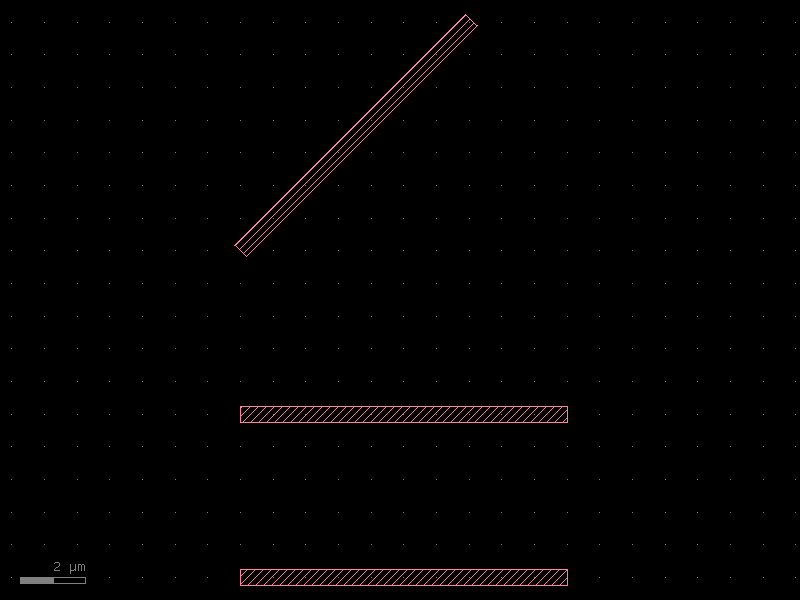

In [6]:
c = kf.KCell(name="transform_demo")
s = kf.cells.straight.straight(length=10, width=0.5, layer=L.WG)

inst_a = c << s
inst_b = c << s
inst_c = c << s

inst_b.transform(kf.kdb.DTrans(0.0, 5.0))        # shift 5 µm north
inst_c.transform(kf.kdb.DCplxTrans(1, 45, False, 0, 10))  # shift + rotate 45°

c

## Connecting instances by port

`instance.connect("port_name", target_port)` moves and rotates the instance so that
the named port aligns face-to-face with `target_port`.  This is the standard way to
assemble photonic circuits.

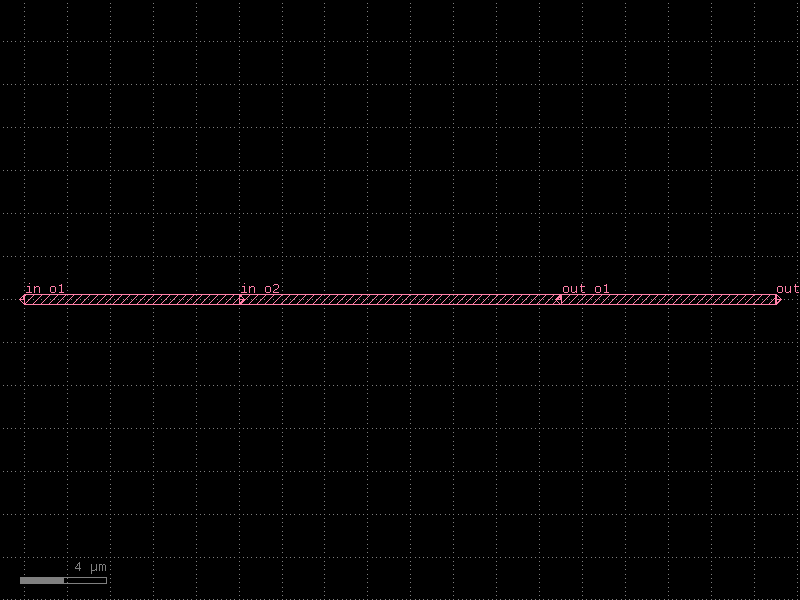

In [7]:
circuit = kf.KCell(name="chained_straights")

seg1 = circuit << kf.cells.straight.straight(length=10, width=0.5, layer=L.WG)
seg2 = circuit << kf.cells.straight.straight(length=15, width=0.5, layer=L.WG)
seg3 = circuit << kf.cells.straight.straight(length=10, width=0.5, layer=L.WG)

seg2.connect("o1", seg1.ports["o2"])
seg3.connect("o1", seg2.ports["o2"])

circuit.add_ports(seg1.ports, prefix="in_")
circuit.add_ports(seg3.ports, prefix="out_")
circuit.draw_ports()
circuit

### Mirrored connections

Pass `mirror=True` to reflect the instance before alignment.  This is useful when
two ports face the same direction (e.g. building a U-bend from two 90° bends).

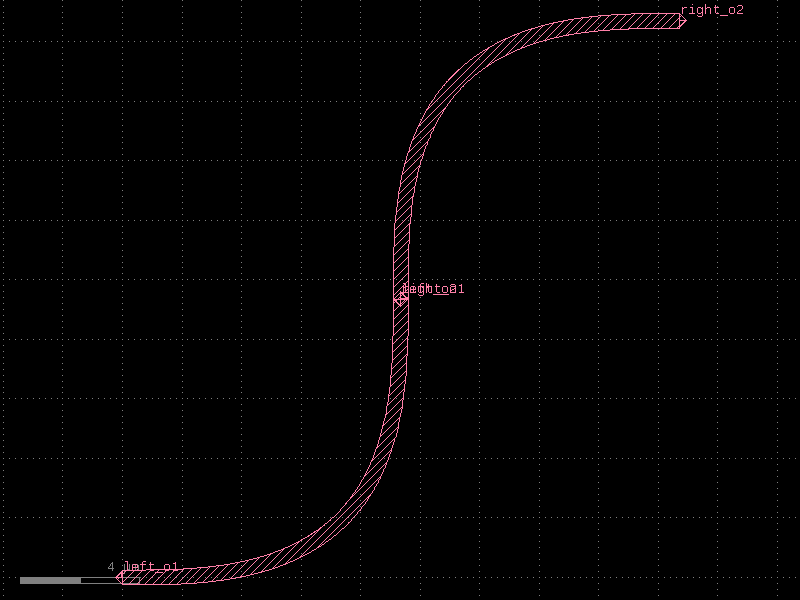

In [8]:
bend = kf.cells.euler.bend_euler(radius=5, width=0.5, layer=L.WG, angle=90)

u_bend = kf.KCell(name="u_bend")
b1 = u_bend << bend
b2 = u_bend << bend
b2.connect("o1", b1.ports["o2"], mirror=True)

u_bend.add_ports(b1.ports, prefix="left_")
u_bend.add_ports(b2.ports, prefix="right_")
u_bend.draw_ports()
u_bend

## Arrays of instances

`create_inst(cell, na=N, nb=M, a=vec_a, b=vec_b)` creates a regular NxM array
using a single GDS `AREF` record — very compact in the output file.

> **Note:** Array elements cannot have individual ports; use individual instances
> when you need per-element port access.

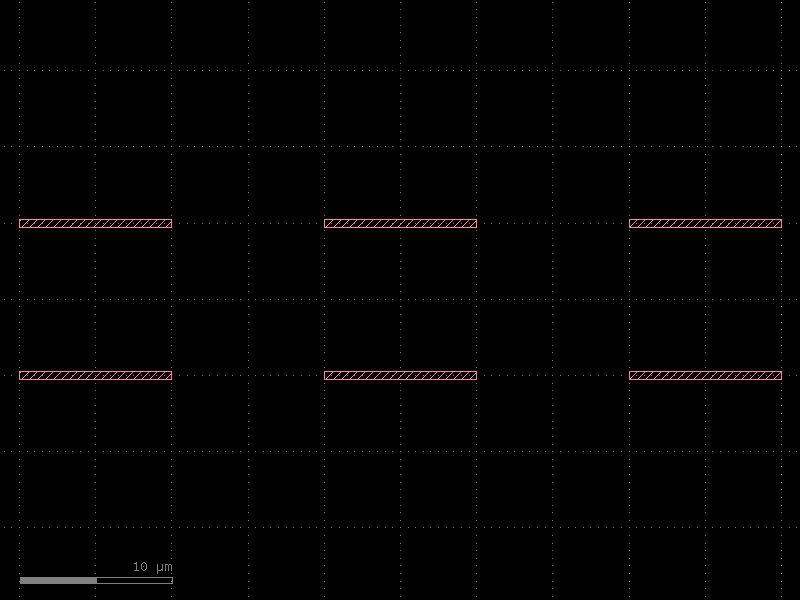

In [9]:
tile = kf.cells.straight.straight(length=10, width=0.5, layer=L.WG)

grid = kf.KCell(name="instance_array")
arr = grid.create_inst(
    tile,
    na=3, nb=2,           # 3 columns, 2 rows
    a=(20_000, 0),        # 20 µm step in x  (DBU = nm)
    b=(0, 10_000),        # 10 µm step in y
)
grid.draw_ports()
grid

Ports of array elements are accessed via `inst[port_name, col, row]`:

In [10]:
print("Port at column 0, row 1:", arr["o1", 0, 1])
print("Port at column 2, row 0:", arr["o2", 2, 0])

Port at column 0, row 1: Port(self.name='o1', self.width=500, trans=r180 *1 0,10, layer=WG (1/0), port_type=optical)
Port at column 2, row 0: Port(self.name='o2', self.width=500, trans=r0 *1 50,0, layer=WG (1/0), port_type=optical)


## Hierarchical nesting

Instances can point to cells that themselves contain instances.  There is no practical
depth limit — kfactory and KLayout handle deep hierarchy natively.

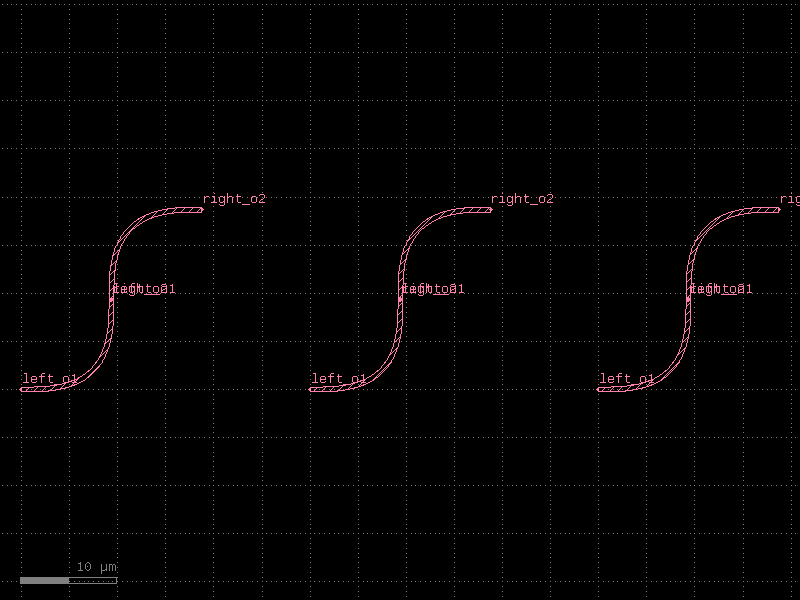

In [11]:
top = kf.KCell(name="top_level")
r1 = top << u_bend
r2 = top << u_bend
r3 = top << u_bend

r1.transform(kf.kdb.DTrans(0.0, 0.0))
r2.transform(kf.kdb.DTrans(30.0, 0.0))
r3.transform(kf.kdb.DTrans(60.0, 0.0))

top

## Flattening non-Manhattan connections

When you `connect` at a non-90° angle the sub-cell boundary and the parent boundary
can produce sub-nanometre gaps at the interface.  Calling `instance.flatten()` merges
the instance geometry into the parent, eliminating those gaps.

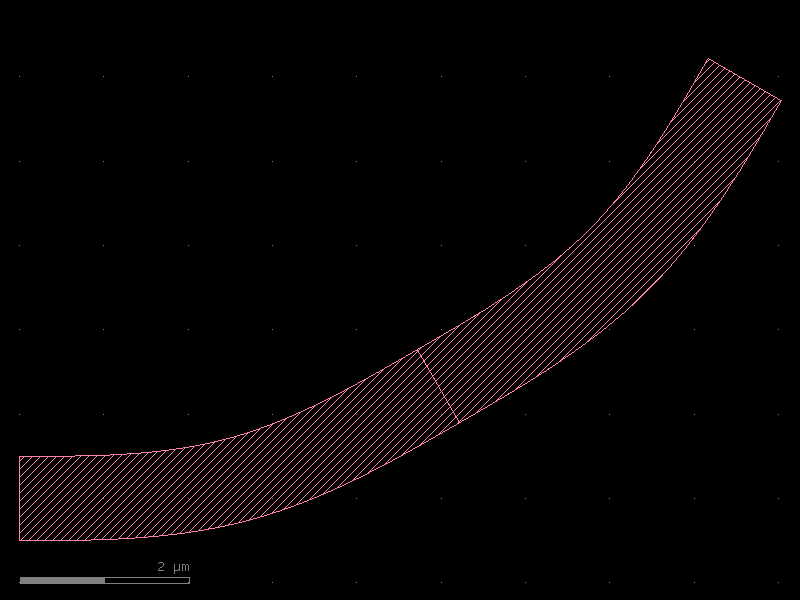

In [12]:
angled = kf.KCell(name="angled_connect")
b30a = angled << kf.cells.euler.bend_euler(radius=5, width=1, layer=L.WG, angle=30)
b30b = angled << kf.cells.euler.bend_euler(radius=5, width=1, layer=L.WG, angle=30)
b30b.connect("o1", b30a.ports["o2"])
b30b.flatten()   # merges geometry into parent to close sub-nm gaps
angled

## Summary

| Task | API |
|------|-----|
| Place a child cell | `parent.create_inst(child)` or `inst = parent << child` |
| Reposition | `inst.transform(kf.kdb.DTrans(x, y))` |
| Connect face-to-face | `inst.connect("port", other_port)` |
| Connect with mirror | `inst.connect("port", other_port, mirror=True)` |
| Regular array | `parent.create_inst(child, na=N, nb=M, a=vec_a, b=vec_b)` |
| Access array port | `arr_inst["port_name", col, row]` |
| Expose child ports | `parent.add_ports(inst.ports, prefix="…")` |
| Flatten into parent | `inst.flatten()` |

## See Also

| Topic | Where |
|-------|-------|
| Port system used by `connect()` | [Core Concepts: Ports](ports.py) |
| Routing between instance ports | [Routing: Overview](../routing/overview.py) |
| Assembling multi-cell components | [Components: Overview](../components/cells/overview.py) |
| Grid and tiling arrays of instances | [Utilities: Grid Layout](../utilities/grid.py) |